### **获取数据**

In [2]:
from sklearn.datasets import load_iris

iris_datas = load_iris()  # 获取数据
print(iris_datas.keys())  # 查看数据集的键
# print(iris_datas.data)  # 特征数据
print(iris_datas.data.shape)  # 查看特征数据集的维度
print(iris_datas.feature_names)  # 特征名称
print(iris_datas.target)  # 标签数据 0,1,2,
print(iris_datas.target_names)  # 标签名称

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
(150, 4)
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
['setosa' 'versicolor' 'virginica']


### **绘制散点图**

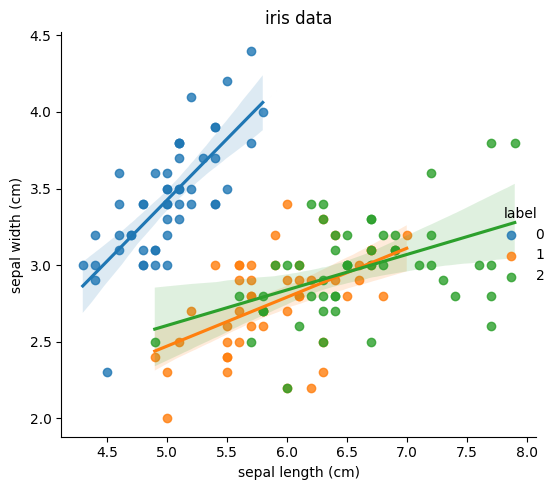

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
# 新增标签列
iris_df['label'] = iris.target
# 绘制散点图
sns.lmplot(
    x='sepal length (cm)',
    y='sepal width (cm)',
    hue='label',
    data=iris_df,
    fit_reg=True  # fit_reg=False 表示没有辅助线
)
plt.title('iris data')
plt.tight_layout()
plt.show()

### **切割数据集和测试集**
    从总的数据中,按照一点的比例,切分训练集和测试集
    训练集用于训练模型,测试集用来测试模型的准确性

In [5]:
from sklearn.model_selection import train_test_split

iris = load_iris()
test_size = 0.2  # 切割比例 数据集占80%,测试集占20%
random_state = 1  #随机种子,确保随机生成的数据集都是固定的
x_train, x_test, y_train, y_test = train_test_split(
    iris.data,
    iris.target,
    test_size=test_size,
    random_state=random_state
)
print("训练集的个数", x_train.shape)
print("测试集的个数", x_test.shape)
print("训练集的标签", y_train)
print("测试集的标签", y_test)


训练集的个数 (120, 4)
测试集的个数 (30, 4)
训练集的标签 [1 2 1 2 2 0 1 0 1 2 2 0 2 2 1 2 0 0 0 1 0 0 2 2 2 2 2 1 2 1 0 2 2 0 0 2 0
 2 2 1 1 2 2 0 1 1 2 1 2 1 0 0 0 2 0 1 2 2 0 0 1 0 2 1 2 2 1 2 2 1 0 1 0 1
 1 0 1 0 0 2 2 2 0 0 1 0 2 0 2 2 0 2 0 1 0 1 1 0 0 1 0 1 1 0 1 1 1 1 2 0 0
 2 1 2 1 2 2 1 2 0]
测试集的标签 [0 1 1 0 2 1 2 0 0 2 1 0 2 1 1 0 1 1 0 0 1 1 1 0 2 1 0 0 1 2]


 ### **训练模型**

In [6]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

#
# iris = load_iris()
# test_size = 0.2  # 切割比例 数据集占80%,测试集占20%
# random_state = 1  #随机种子,确保随机生成的数据集都是固定的
# x_train, x_test, y_train, y_test = train_test_split(
#     iris.data,
#     iris.target,
#     test_size=test_size,
#     random_state=random_state
# )

# 对特征进行预处理,此处使用标准化
transfer = StandardScaler()

# fit_transfer: 先训练,再转换,兼具fit和transfer的功能,第一次进行标准化时使用,一般用于处理训练集
x_train = transfer.fit_transform(x_train)

# transform: 只有转换,适用于需要重复进行标准化动作时使用,一般用于处理测试集
x_test = transfer.transform(x_test)

# 训练模型
estimator = KNeighborsClassifier(n_neighbors=5)
estimator.fit(x_train, y_train)

# 模型预测
# 预测切割的数据集
y_predict = estimator.predict(x_test)
print("预测结果", y_predict)

# 预测自定义测试集
my_data = [[7.8, 2.1, 3.9, 1.6]]
my_transfer = transfer.transform(my_data)
my_predict = estimator.predict(my_transfer)
print("自定义测试集预测结果", my_predict)

# 查看预测的准确率
my_proba = estimator.predict_proba(my_transfer)
print("预测的概率", my_proba)

# 模型评估
# 方式1:直接评分,基于: 测试集的特征 和 测试集的标签,评估100个样本中,模型预测对了多少个
print("准确率", estimator.score(x_test, y_test))
# 方式2:基于: 测试集的标签 和 预测结果
print("准确率", accuracy_score(y_test, y_predict))

预测结果 [0 1 1 0 2 1 2 0 0 2 1 0 2 1 1 0 1 1 0 0 1 1 2 0 2 1 0 0 1 2]
自定义测试集预测结果 [1]
预测的概率 [[0.  0.8 0.2]]
准确率 0.9666666666666667
准确率 0.9666666666666667


## **交叉验证和网格搜索**

### **交叉验证**


  **目的**: 为了让模型的最终结果尽可能的准确

  **原理**:
        把数据分成n份(n折交叉验证):

        第1次: 第1份作为测试集,剩余的n-1份作为训练集,训练模型,预测第1份的标签,得到准确率1

        第2次: 第2份作为测试集,剩余的n-1份作为训练集,训练模型,预测第2份的标签,得到准确率2

        ...

        第n次: 第n份作为测试集,剩余的n-1份作为训练集,训练模型,预测第n份的标签,得到准确率n

  计算上述的准确率,并求平均,得到最终准确率

  假设第k次最好(准确率最高的),则用全部数据训练模型,再次使用第k次的测试集对模型进行测试.

### **网格搜索**

**目的**: 找到模型中,最合适的参数

**原理**: 接受参数可能出现的值,然后针对每个值进行**交叉验证**,得到最优参数

In [9]:
from sklearn.model_selection import GridSearchCV

# 1.加载数据
iris = load_iris()
test_size = 0.2  # 切割比例 数据集占80%,测试集占20%
random_state = 1  #随机种子,确保随机生成的数据集都是固定的
# 2.切割数据集和测试集
x_train, x_test, y_train, y_test = train_test_split(
    iris.data,
    iris.target,
    test_size=test_size,
    random_state=random_state
)
# 3.对特征进行预处理,此处使用标准化
transfer = StandardScaler()

# fit_transfer: 先训练,再转换,兼具fit和transfer的功能,第一次进行标准化时使用,一般用于处理训练集
x_train = transfer.fit_transform(x_train)

# transform: 只有转换,适用于需要重复进行标准化动作时使用,一般用于处理测试集
x_test = transfer.transform(x_test)

# 4.训练模型
# 定义参数,可能出现的值
parm_dict = {
    'n_neighbors': [i for i in range(1, 11)]
}
# 创建KNN分类模型对象
estimator = KNeighborsClassifier()
# 创建网格搜索对象
# 参数1: 模型对象,参数2: 参数可能出现的值,参数3: 交叉验证的次数
grid_estimator = GridSearchCV(estimator, parm_dict, cv=4)
# 训练
grid_estimator.fit(x_train, y_train)
print('最优评分: ', grid_estimator.best_score_)
print('最优参数: ', grid_estimator.best_params_)
print('最优评估器对象: ', grid_estimator.best_estimator_)
# print("具体的交叉验证结果: ", grid_estimator.cv_results_)

# 5.模型评估,将上述得到的最优参数进行测试
# estimator = grid_estimator.best_estimator_ # 获取最优模型对象
estimator = KNeighborsClassifier(n_neighbors=5)  # 手动创建模型对象
estimator.fit(x_train, y_train)
y_pre = estimator.predict(x_test)
print("准确率: ", accuracy_score(y_test, y_pre))

最优评分:  0.9583333333333334
最优参数:  {'n_neighbors': 5}
最优评估器对象:  KNeighborsClassifier()
准确率:  0.9666666666666667
